# 流行音乐数据分析：什么性格的年轻人喜欢什么样的流行歌手

**大数据专业个人项目** · Python + scikit-learn 全流程分析

---

### 分析链路

```
年轻人问卷(性格+流派偏好) ──► 性格画像聚类 ──► 画像×流派偏好 ──┐
                                                              ├──► 画像 → 流派 → 代表歌手
歌曲库(歌手+流派+音频特征) ──► 流行度回归 ────────────────────┘
```

### 三个可验证的子问题

1. 年轻人按性格可以分成哪几类画像？—— **聚类（K-Means + 层次聚类）**
2. 能否用人口学与兴趣爱好预测一个人属于哪个画像？—— **分类（逻辑回归/决策树/随机森林）**
3. 什么样的歌更容易流行？—— **回归（线性回归 vs 随机森林）**

## 0. 环境与数据准备

本报告读取 `data/processed/` 下的清洗结果与 `outputs/` 下的图表、结果表。

> 若提示文件不存在，请先在项目根目录按顺序运行：
> `python src/01_download_data.py` → `02_clean_eda.py` → `03_cluster_personality.py`
> → `04_classify_profile.py` → `05_regression_popularity.py` → `06_singer_mapping.py`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

# 让 Notebook 无论从哪个目录启动都能找到项目根目录
ROOT = Path.cwd()
while not (ROOT / "src" / "config.py").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

FIG = ROOT / "outputs" / "figures"
TAB = ROOT / "outputs" / "tables"


def show_fig(name, width=780):
    """展示 outputs/figures 下的图表。"""
    path = FIG / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f"[缺失] {path}，请先运行 src 下的分析脚本")


def show_table(name, **kw):
    """展示 outputs/tables 下的结果表。"""
    path = TAB / name
    if path.exists():
        df = pd.read_csv(path, index_col=0 if kw.pop("index", False) else None)
        display(df)
        return df
    print(f"[缺失] {path}")
    return None


pd.set_option("display.unicode.east_asian_width", True)
print("项目根目录:", ROOT)

项目根目录: E:\流行音乐数据分析


## 1. 数据来源与概览

| 数据集 | 内容 | 规模 |
|--------|------|------|
| Young People Survey (Kaggle) | 15~30 岁年轻人：17 个音乐流派 1-5 分偏好、性格与生活态度、人口学 | 1010 人 × 150 列 |
| Spotify Songs (TidyTuesday) | 六大流派歌曲的歌手、流行度、11 个音频特征 | 32833 首（去重后 28356 首），10692 位歌手 |

两份数据通过**流派**这一共同维度桥接。

In [2]:
survey = pd.read_csv(ROOT / "data/processed/survey_with_cluster.csv")
spotify = pd.read_csv(ROOT / "data/processed/spotify_clean.csv")
spotify_uniq = spotify.drop_duplicates(subset="track_id")

print(f"问卷数据: {survey.shape[0]} 人 × {survey.shape[1]} 列")
print(f"歌曲数据: 原始 {spotify.shape[0]} 行 -> 按 track_id 去重 {spotify_uniq.shape[0]} 首")
print(f"覆盖歌手: {spotify_uniq['track_artist'].nunique()} 位")
print()
print("问卷关键字段示例（人口学 + 性格代理指标）:")
display(survey[["Age", "Gender", "Education", "外向社交", "尽责自律",
                "情绪稳定", "开放好奇", "宜人友善"]].head())

问卷数据: 1010 人 × 157 列
歌曲数据: 原始 32833 行 -> 按 track_id 去重 28356 首
覆盖歌手: 10692 位

问卷关键字段示例（人口学 + 性格代理指标）:


,Age,Gender,Education,外向社交,尽责自律,情绪稳定,开放好奇,宜人友善
0,20.0,female,college/bachelor degree,3.714286,3.428571,4.1875,3.125,3.625
1,19.0,female,college/bachelor degree,3.000000,4.000000,4.0000,2.625,2.750
2,20.0,female,secondary school,4.428571,3.571429,4.1250,4.250,3.625
3,22.0,female,college/bachelor degree,1.571429,4.000000,2.1250,3.250,2.625
4,20.0,female,secondary school,3.000000,3.285714,4.1250,2.500,2.875


## 2. 数据清洗与性格维度合成

原始问卷 150 列中有 144 列存在缺失，总缺失率仅 **0.4%**：量表题用中位数填补，
分类题用众数填补。文字选项题（守时、诚实度）序数编码为 1-5 分。

**性格维度合成**：基于大五人格框架，把问卷中语义对应的题目平均成 5 个代理指标，
「情绪稳定」由负向题反向计分得到：

| 维度 | 来源题目（示例） |
|------|------------------|
| 外向社交 | 与朋友玩乐、社交、朋友数量、精力水平、跳舞 |
| 尽责自律 | 可靠性、守信、守时、工作优先、未雨绸缪 |
| 情绪稳定 | 生活挫折、情绪波动、易怒、孤独（**反向计分**） |
| 开放好奇 | 艺术展览、戏剧、阅读、外语、心理学 |
| 宜人友善 | 共情、爱护动物、给予、慈善、诚实度 |

> ⚠️ 这是问卷单题合成的**代理指标**，非标准化大五人格量表（如 NEO-PI-R）。

,尽责自律,情绪稳定,开放好奇,宜人友善
外向社交,,,,
1010.000,1010.000,1010.000,1010.000,1010.000
3.329,3.296,3.350,2.892,3.310
0.654,0.697,0.604,0.744,0.510
1.429,1.429,1.500,1.000,1.750
3.000,2.714,2.938,2.375,3.000
3.286,3.286,3.375,2.875,3.375
3.857,3.714,3.750,3.469,3.625
5.000,5.000,4.875,5.000,4.750


,尽责自律,情绪稳定,开放好奇,宜人友善
外向社交,,,,
1010.000,1010.000,1010.000,1010.000,1010.000
3.329,3.296,3.350,2.892,3.310
0.654,0.697,0.604,0.744,0.510
1.429,1.429,1.500,1.000,1.750
3.000,2.714,2.938,2.375,3.000
3.286,3.286,3.375,2.875,3.375
3.857,3.714,3.750,3.469,3.625
5.000,5.000,4.875,5.000,4.750


,平均分,流派中文
Dance,3.113,舞曲
Folk,2.287,民谣
Country,2.123,乡村
Classical music,2.956,古典
Musical,2.762,音乐剧
Pop,3.473,流行
Rock,3.763,摇滚
Metal or Hardrock,2.360,金属/硬摇
Punk,2.452,朋克
"Hiphop, Rap",2.911,嘻哈/说唱


,平均分,流派中文
Dance,3.113,舞曲
Folk,2.287,民谣
Country,2.123,乡村
Classical music,2.956,古典
Musical,2.762,音乐剧
Pop,3.473,流行


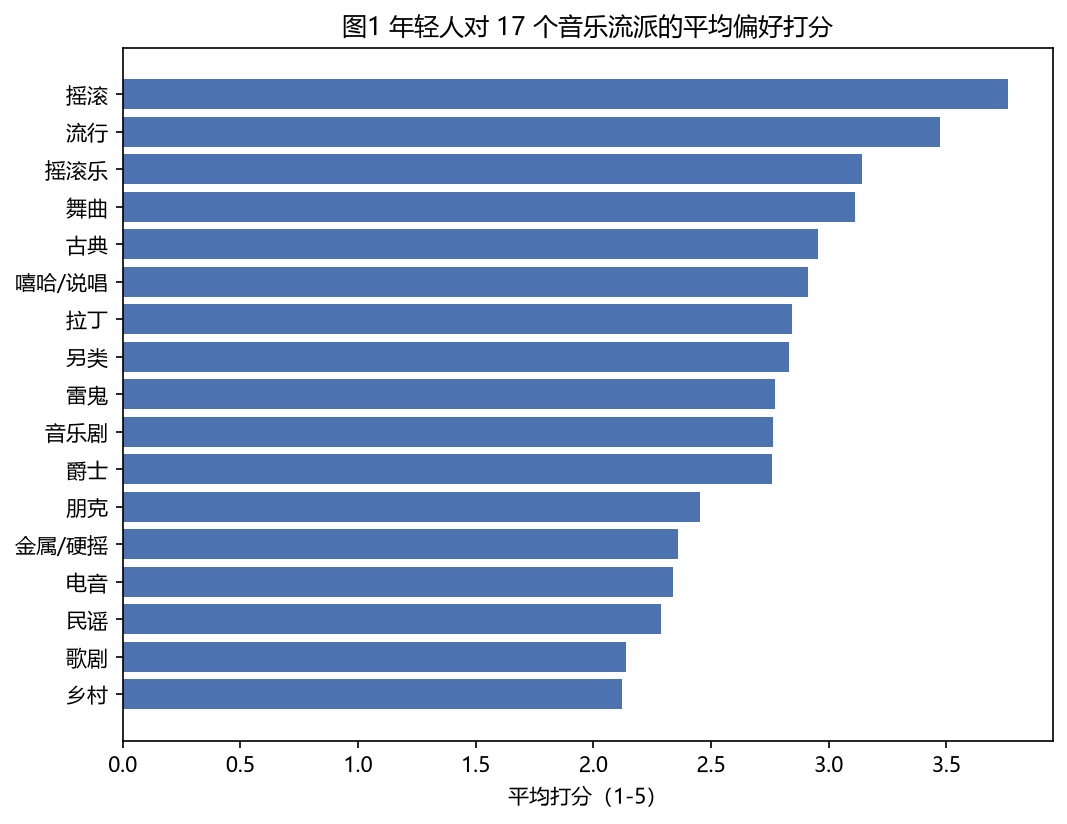

In [3]:
display(show_table("survey_proxy_describe.csv", index=True))
display(show_table("survey_genre_means.csv", index=True).head(6))
show_fig("fig01_survey_genre_means.png", 720)

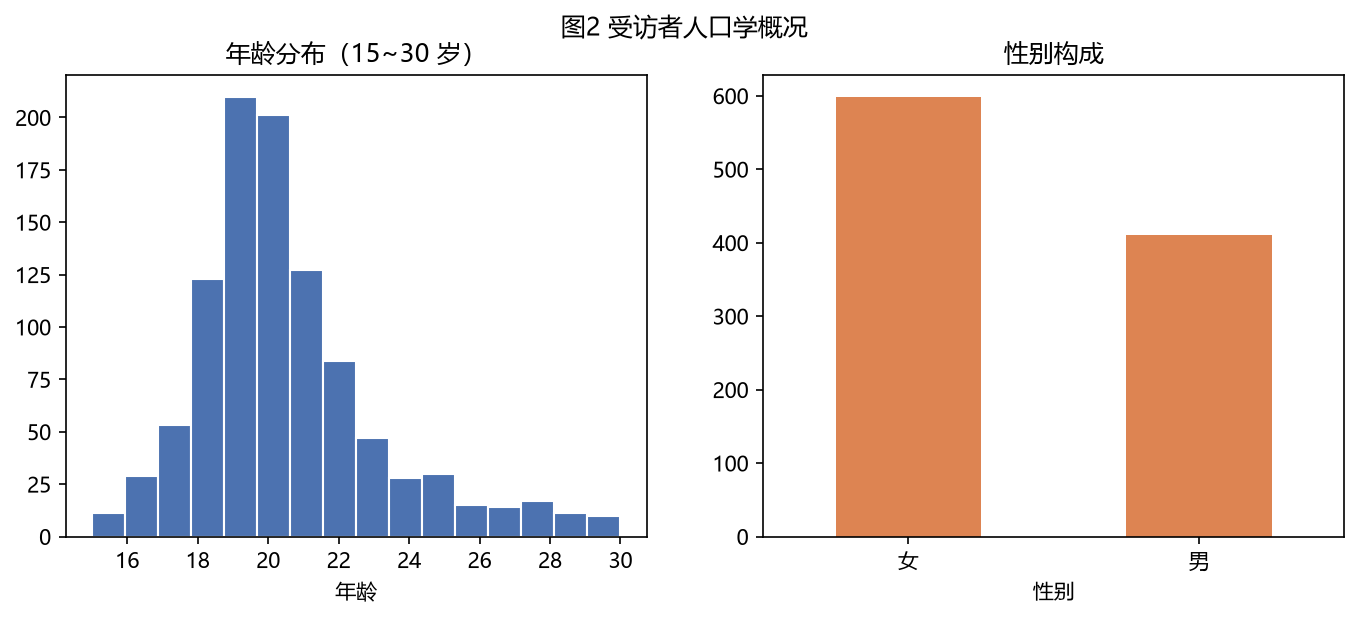

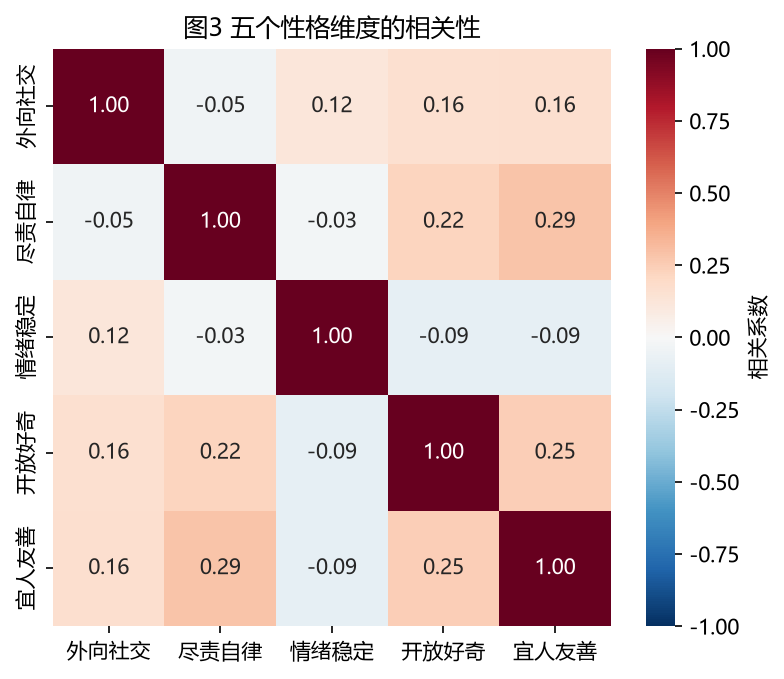

In [4]:
show_fig("fig02_survey_age_gender.png", 900)
show_fig("fig03_proxy_corr_heatmap.png", 600)

## 3. 性格聚类：年轻人可分为哪几类画像？

**定 K 规则**：肘部法则看趋势，轮廓系数定候选，取「轮廓系数 ≥ 最优值 90% 的最大 K」。

实测所有 K 的轮廓系数均低于 0.2，说明年轻人的性格**不存在泾渭分明的分群**。
若直接取轮廓系数最大的 K=2，画像过于粗糙，因此在可接受的质量损失内选择更细的 K。

,inertia,silhouette
K,,
2,4021.4598,0.1870
3,3494.5549,0.1699
4,3159.8623,0.1673
5,2933.5295,0.1532
6,2763.1090,0.1446
7,2607.4633,0.1484
8,2485.2264,0.1404
9,2370.9726,0.1439
10,2281.2292,0.1441


,inertia,silhouette
K,,
2,4021.4598,0.1870
3,3494.5549,0.1699
4,3159.8623,0.1673
5,2933.5295,0.1532
6,2763.1090,0.1446
7,2607.4633,0.1484
8,2485.2264,0.1404
9,2370.9726,0.1439
10,2281.2292,0.1441


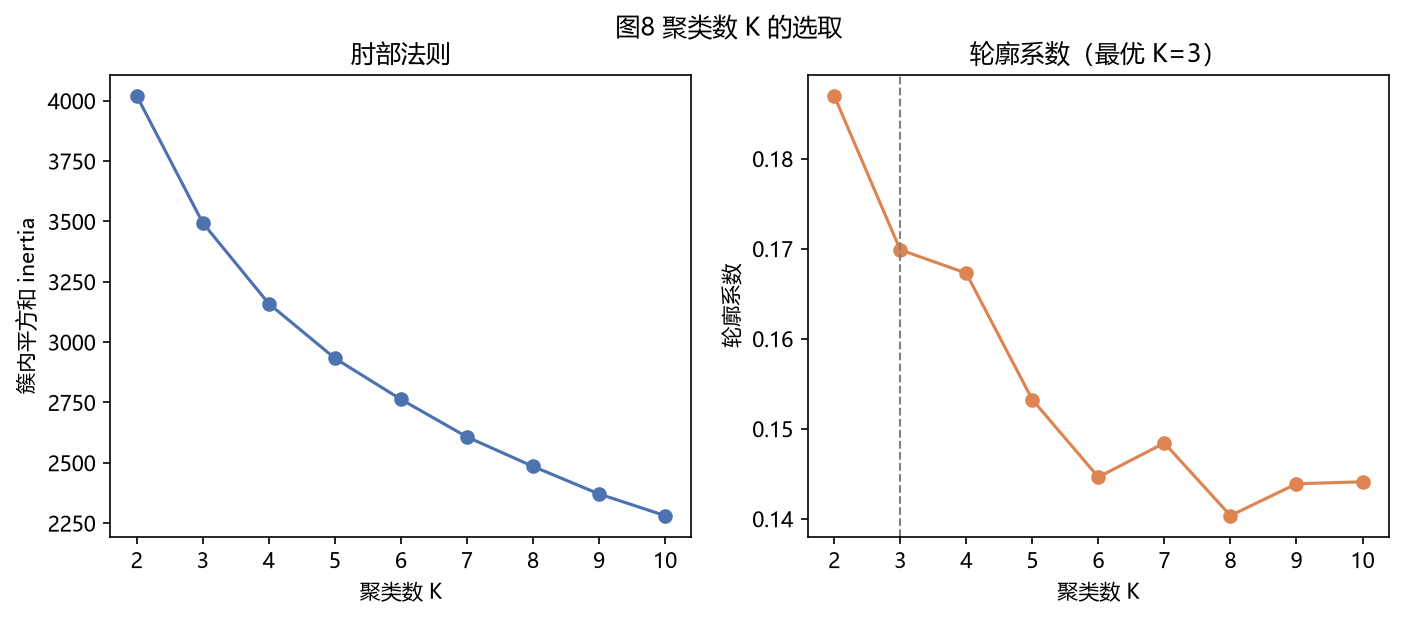

In [5]:
display(show_table("cluster_k_selection.csv", index=True))
show_fig("fig08_cluster_k_selection.png", 900)

,外向社交,尽责自律,情绪稳定,开放好奇,宜人友善
cluster_name,,,,,
尽责自律·宜人友善型,-0.874,0.257,-0.607,-0.348,-0.121
开放好奇·宜人友善型,0.545,0.493,-0.033,0.797,0.695
情绪稳定·外向社交型,0.215,-0.747,0.580,-0.522,-0.619


,外向社交,尽责自律,情绪稳定,开放好奇,宜人友善
cluster_name,,,,,
尽责自律·宜人友善型,-0.874,0.257,-0.607,-0.348,-0.121
开放好奇·宜人友善型,0.545,0.493,-0.033,0.797,0.695
情绪稳定·外向社交型,0.215,-0.747,0.580,-0.522,-0.619


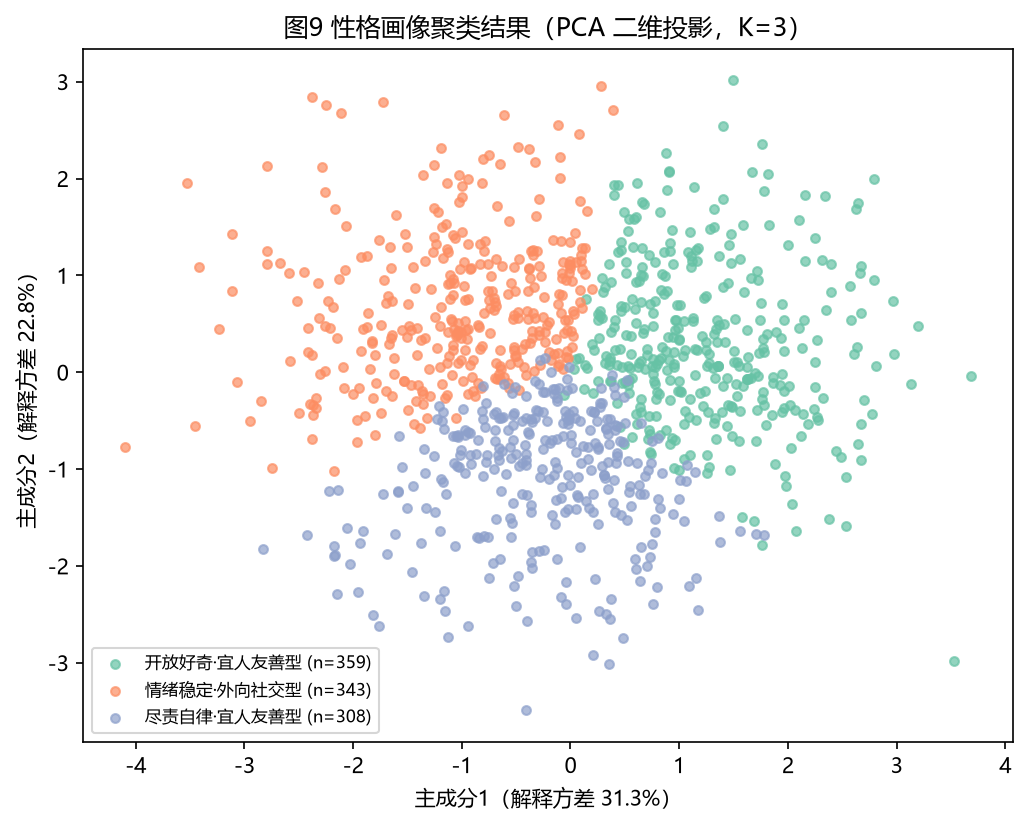

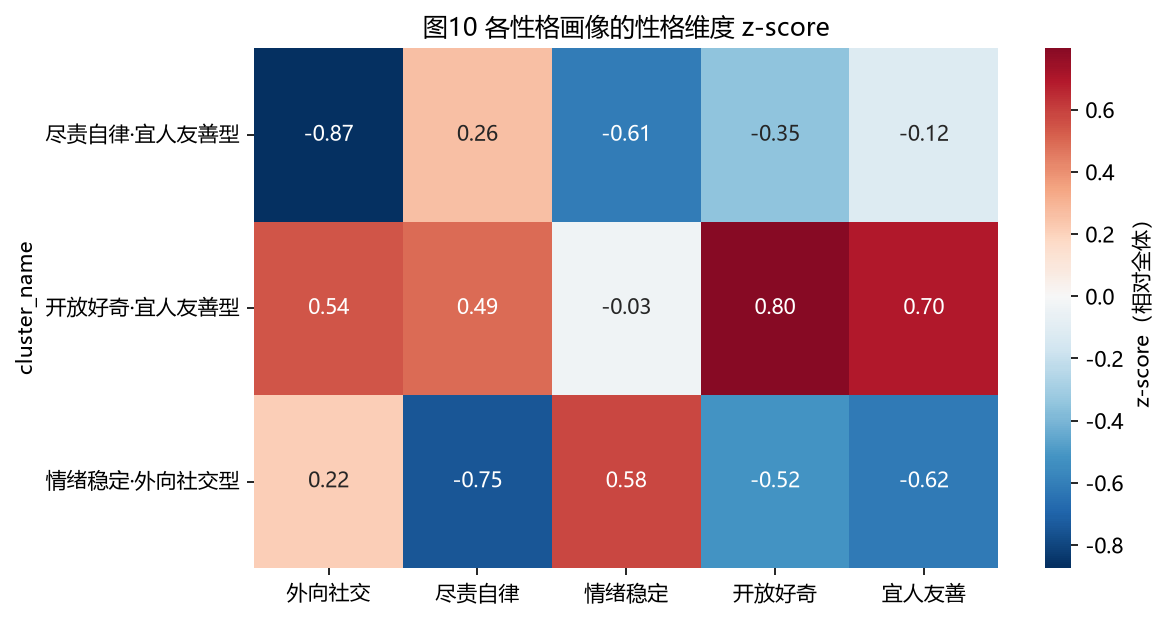

In [6]:
display(show_table("profile_traits_zscore.csv", index=True))
show_fig("fig09_cluster_pca.png", 720)
show_fig("fig10_profile_traits.png", 760)

In [7]:
display(show_table("profile_demographics.csv", index=True))

,人数,平均年龄,女性占比,城市占比
cluster_name,,,,
尽责自律·宜人友善型,308,20.50,0.69,0.69
开放好奇·宜人友善型,359,20.69,0.73,0.69
情绪稳定·外向社交型,343,20.10,0.36,0.73


,人数,平均年龄,女性占比,城市占比
cluster_name,,,,
尽责自律·宜人友善型,308,20.50,0.69,0.69
开放好奇·宜人友善型,359,20.69,0.73,0.69
情绪稳定·外向社交型,343,20.10,0.36,0.73


### 3.1 画像之间的流派偏好差异显著吗？

只看均值差异不够，用 **Kruskal-Wallis 非参数检验**（不假设正态分布，适合 1-5 有序打分）
筛掉不显著的流派，避免把噪声当结论。

,流派,H统计量,p值,显著(p<0.05)
0,音乐剧,82.187261,0.000000,是
1,歌剧,77.611374,0.000000,是
2,拉丁,65.161149,0.000000,是
3,爵士,61.838069,0.000000,是
4,古典,61.778360,0.000000,是
5,民谣,47.862045,0.000000,是
6,摇滚乐,41.992045,0.000000,是
7,另类,22.447800,0.000013,是
8,雷鬼,20.630574,0.000033,是
9,嘻哈/说唱,16.804620,0.000224,是


显著差异流派: 15/17


,流派,H统计量,p值,显著(p<0.05)
0,音乐剧,82.187261,0.000000,是
1,歌剧,77.611374,0.000000,是
2,拉丁,65.161149,0.000000,是
3,爵士,61.838069,0.000000,是
4,古典,61.778360,0.000000,是
5,民谣,47.862045,0.000000,是
6,摇滚乐,41.992045,0.000000,是
7,另类,22.447800,0.000013,是


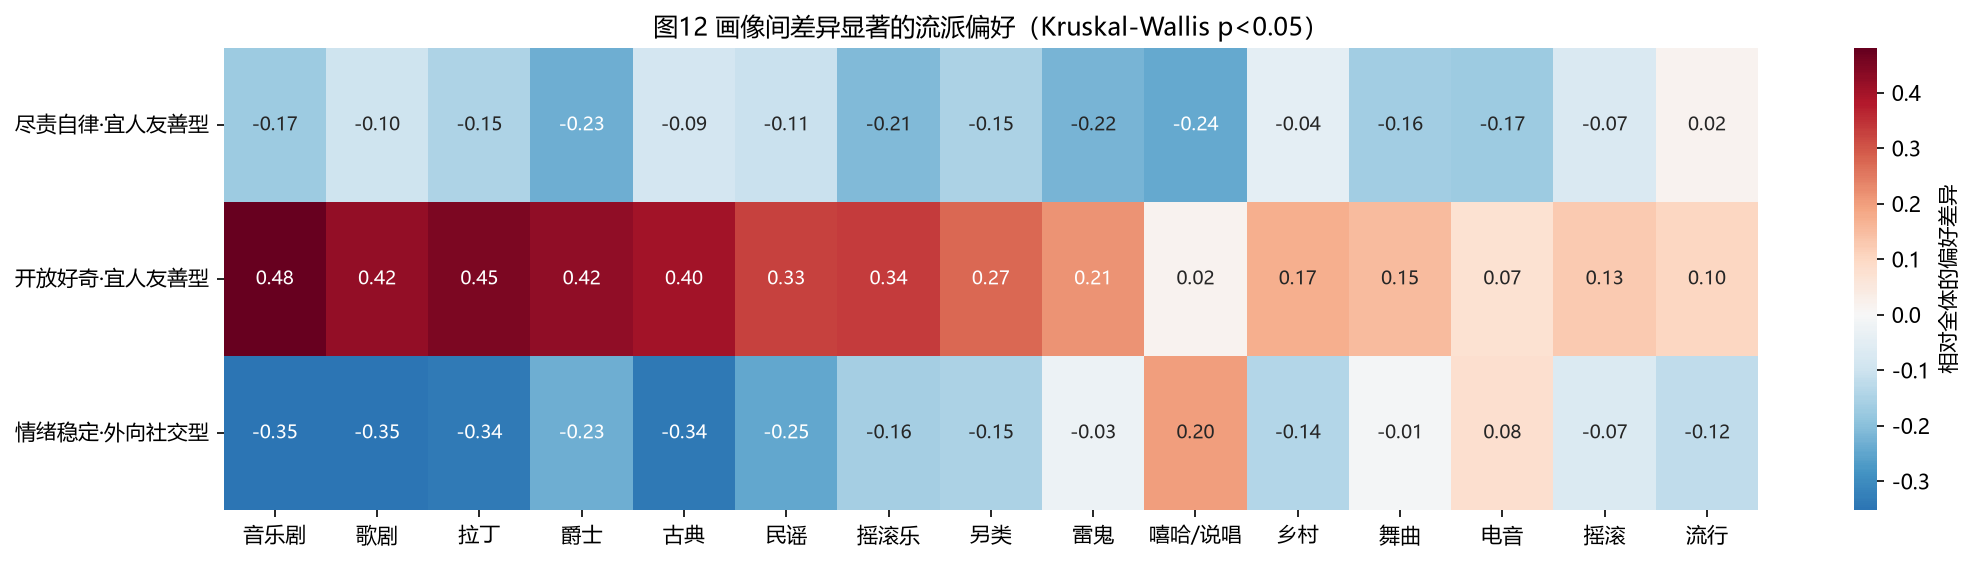

In [8]:
kruskal_df = show_table("profile_genre_kruskal.csv")
n_sig = int((kruskal_df["p值"] < 0.05).sum())
print(f"显著差异流派: {n_sig}/{len(kruskal_df)}")
display(kruskal_df.head(8))
show_fig("fig12_profile_genre_significant.png", 900)

## 4. 画像 × 流派偏好（核心中间产物）

绝对偏好下所有画像都以流行乐居首，看不出差异；改用**相对全体均值的偏好差异**
才能凸显各画像的特征流派。

,舞曲,民谣,乡村,古典,音乐剧,流行,摇滚,金属/硬摇,朋克,嘻哈/说唱,雷鬼,爵士,摇滚乐,另类,拉丁,电音,歌剧
cluster_name,,,,,,,,,,,,,,,,,
尽责自律·宜人友善型,-0.165,-0.109,-0.045,-0.086,-0.171,0.017,-0.072,-0.081,-0.040,-0.242,-0.219,-0.232,-0.212,-0.151,-0.146,-0.174,-0.097
开放好奇·宜人友善型,0.149,0.328,0.172,0.400,0.480,0.101,0.128,0.035,0.096,0.017,0.215,0.422,0.336,0.273,0.449,0.073,0.420
情绪稳定·外向社交型,-0.008,-0.246,-0.140,-0.341,-0.348,-0.120,-0.069,0.036,-0.065,0.200,-0.028,-0.234,-0.161,-0.150,-0.339,0.080,-0.352


,舞曲,民谣,乡村,古典,音乐剧,流行,摇滚,金属/硬摇,朋克,嘻哈/说唱,雷鬼,爵士,摇滚乐,另类,拉丁,电音,歌剧
cluster_name,,,,,,,,,,,,,,,,,
尽责自律·宜人友善型,-0.165,-0.109,-0.045,-0.086,-0.171,0.017,-0.072,-0.081,-0.040,-0.242,-0.219,-0.232,-0.212,-0.151,-0.146,-0.174,-0.097
开放好奇·宜人友善型,0.149,0.328,0.172,0.400,0.480,0.101,0.128,0.035,0.096,0.017,0.215,0.422,0.336,0.273,0.449,0.073,0.420
情绪稳定·外向社交型,-0.008,-0.246,-0.140,-0.341,-0.348,-0.120,-0.069,0.036,-0.065,0.200,-0.028,-0.234,-0.161,-0.150,-0.339,0.080,-0.352


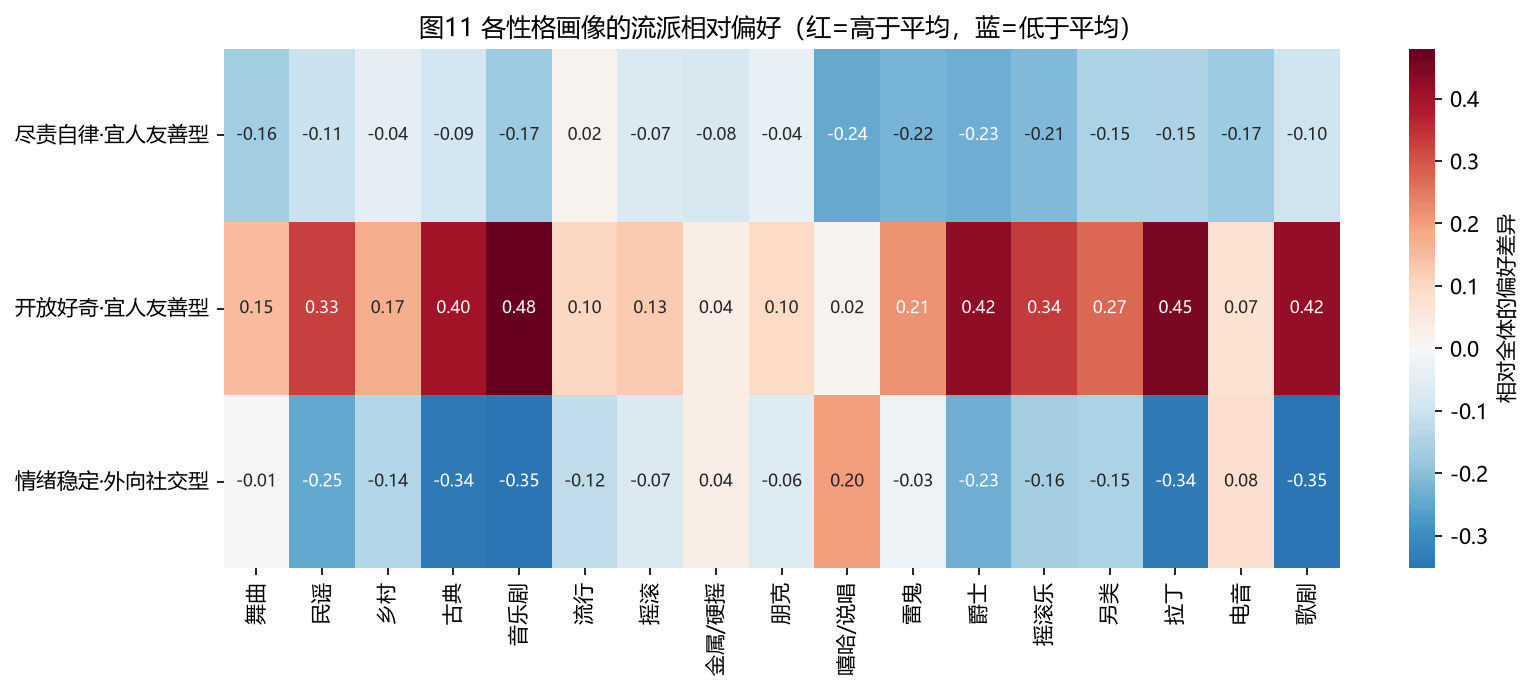

,最爱流派,偏好超出均值,最不爱流派,低于均值,人数
cluster_name,,,,,
尽责自律·宜人友善型,流行,0.02,嘻哈/说唱,-0.24,308
开放好奇·宜人友善型,音乐剧,0.48,嘻哈/说唱,0.02,359
情绪稳定·外向社交型,嘻哈/说唱,0.20,歌剧,-0.35,343


,最爱流派,偏好超出均值,最不爱流派,低于均值,人数
cluster_name,,,,,
尽责自律·宜人友善型,流行,0.02,嘻哈/说唱,-0.24,308
开放好奇·宜人友善型,音乐剧,0.48,嘻哈/说唱,0.02,359
情绪稳定·外向社交型,嘻哈/说唱,0.20,歌剧,-0.35,343


In [9]:
display(show_table("profile_genre_relative.csv", index=True))
show_fig("fig11_profile_genre_heatmap.png", 1000)
display(show_table("profile_favorite_genre.csv", index=True))

## 5. 画像分类：能否用易得信息预测性格画像？

**方法要点（避免循环论证）**：特征刻意排除 5 个性格维度本身（画像由它们聚类而来）
与 17 个流派打分（音乐口味是待预测结果），只用人口学特征与 44 项兴趣爱好。

业务含义：拿到新用户的年龄、性别、学历、上网时长、兴趣，即可预测其性格画像，
进而推荐该画像偏爱的流派与歌手——一个可落地的推荐前置环节。

,模型,准确率,宏平均F1,相对基线提升
0,随机森林,0.6921,0.6856,0.337
1,逻辑回归,0.6762,0.6745,0.321
2,决策树,0.5733,0.5708,0.218


,模型,准确率,宏平均F1,相对基线提升
0,随机森林,0.6921,0.6856,0.337
1,逻辑回归,0.6762,0.6745,0.321
2,决策树,0.5733,0.5708,0.218


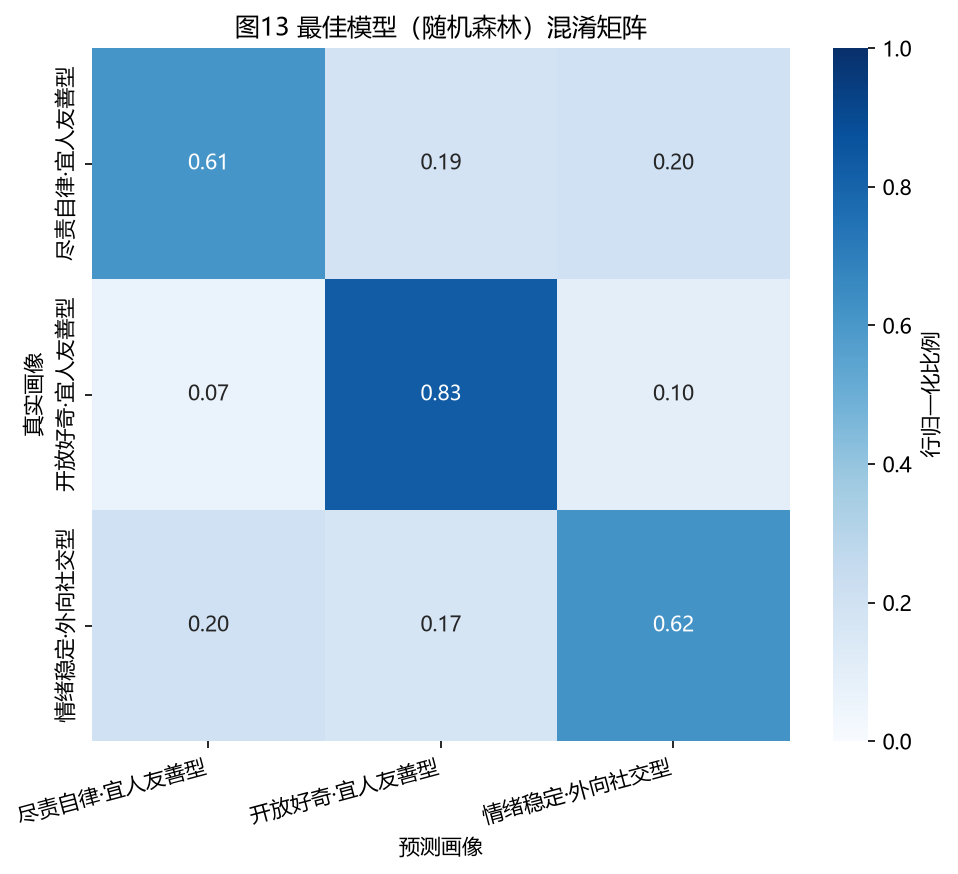

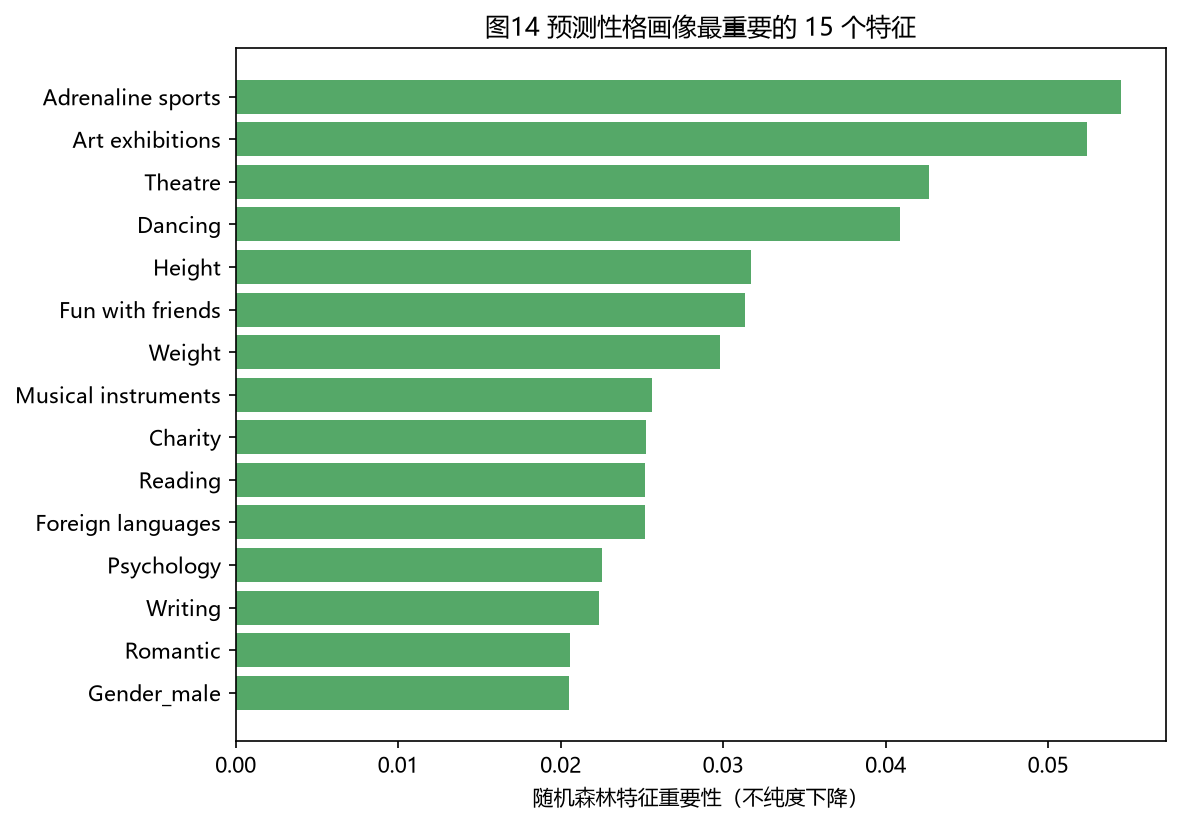

In [10]:
display(show_table("classify_model_comparison.csv"))
show_fig("fig13_classify_confusion.png", 640)
show_fig("fig14_classify_importance.png", 760)

In [11]:
display(show_table("classify_per_class.csv", index=True))

,precision,recall,f1-score
尽责自律·宜人友善型,0.6667,0.6104,0.6373
开放好奇·宜人友善型,0.7181,0.8301,0.7700
情绪稳定·外向社交型,0.6805,0.6210,0.6494


,precision,recall,f1-score
尽责自律·宜人友善型,0.6667,0.6104,0.6373
开放好奇·宜人友善型,0.7181,0.8301,0.7700
情绪稳定·外向社交型,0.6805,0.6210,0.6494


## 6. 流行度回归：什么样的歌容易火？

**关键严谨性处理**：原始数据 32833 行中有 4477 行是同一首歌出现在多个歌单，
建模前按 `track_id` 去重，否则同一首歌会同时落进训练集与测试集，造成信息泄漏、R² 虚高。

同时做**消融对比**，量化「流派」特征带来的增益。

,模型,特征集,R2,RMSE,MAE
0,线性回归(仅音频+年份),仅音频+年份,0.0570,23.0160,19.2645
1,随机森林(仅音频+年份),仅音频+年份,0.1351,22.0433,18.2808
2,线性回归(音频+年份+流派),音频+年份+流派,0.0874,22.6423,18.9107
3,随机森林(音频+年份+流派),音频+年份+流派,0.1729,21.5559,17.7617


,模型,特征集,R2,RMSE,MAE
0,线性回归(仅音频+年份),仅音频+年份,0.0570,23.0160,19.2645
1,随机森林(仅音频+年份),仅音频+年份,0.1351,22.0433,18.2808
2,线性回归(音频+年份+流派),音频+年份+流派,0.0874,22.6423,18.9107
3,随机森林(音频+年份+流派),音频+年份+流派,0.1729,21.5559,17.7617


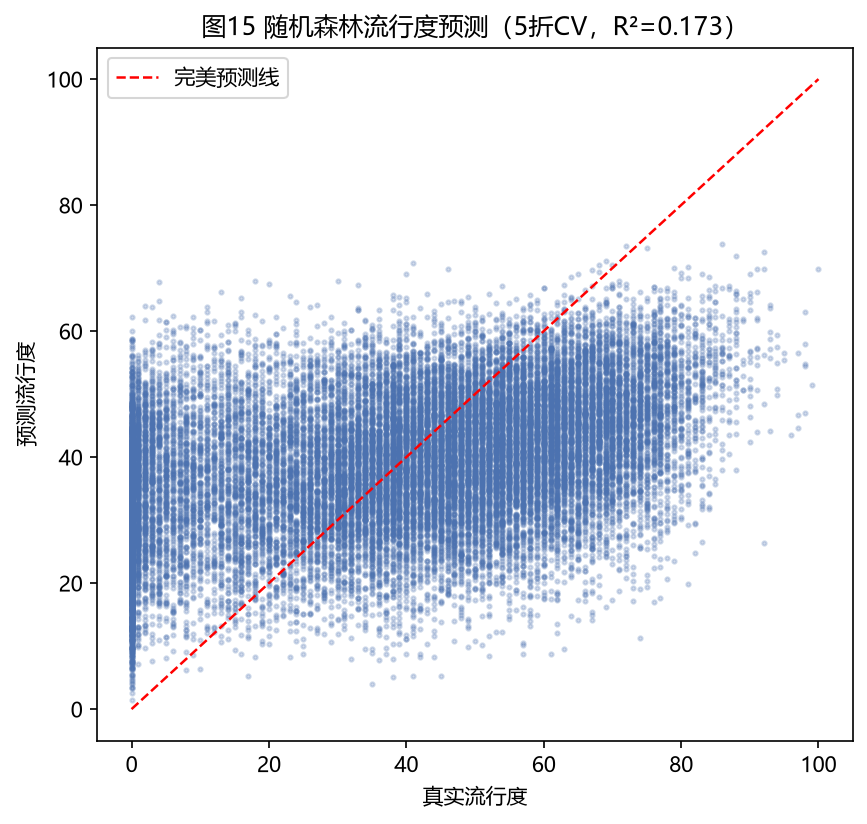

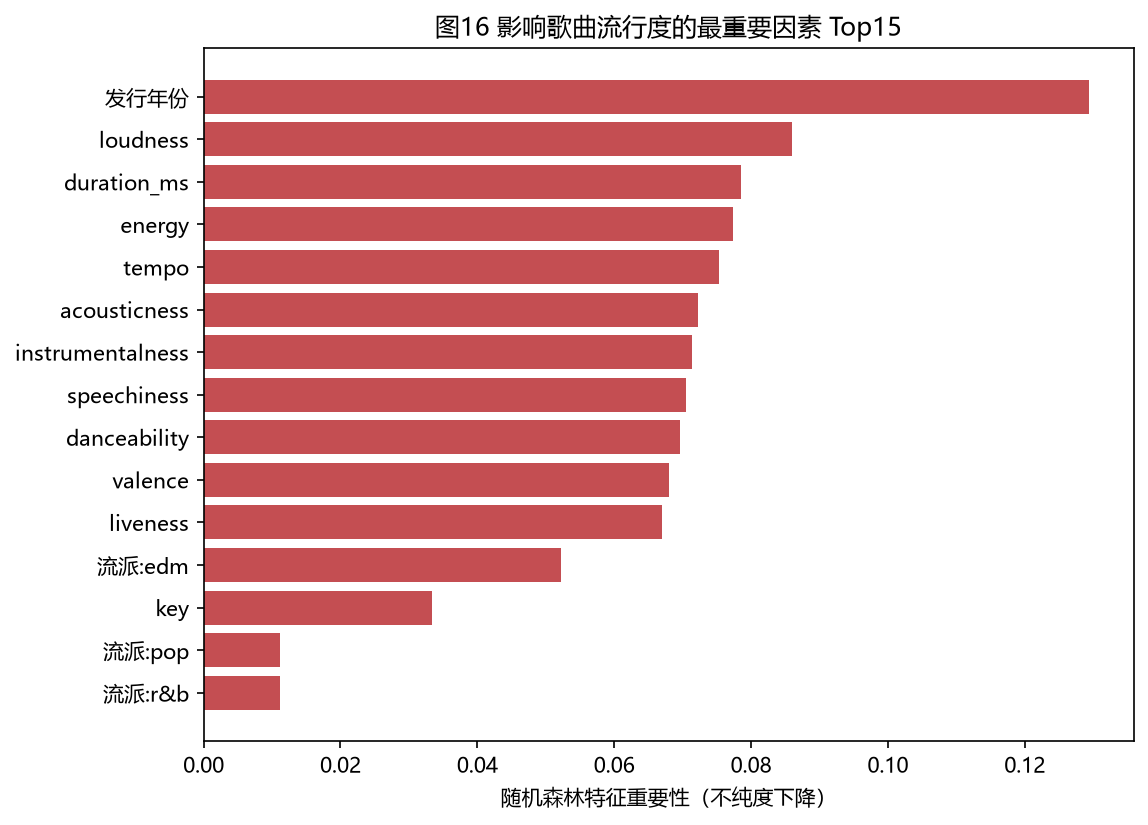

In [12]:
display(show_table("regress_model_comparison.csv"))
show_fig("fig15_regress_pred_scatter.png", 620)
show_fig("fig16_regress_importance.png", 760)

In [13]:
corr = show_table("regress_corr.csv", index=True)
print("音频特征与流行度的相关系数（全部弱于 |0.15|）:")
display(corr)

,与流行度相关系数
duration_ms,-0.1397
instrumentalness,-0.1244
energy,-0.1036
liveness,-0.0528
key,-0.0081
tempo,0.0044
speechiness,0.0052
mode,0.0163
valence,0.0226
loudness,0.0373


音频特征与流行度的相关系数（全部弱于 |0.15|）:


,与流行度相关系数
duration_ms,-0.1397
instrumentalness,-0.1244
energy,-0.1036
liveness,-0.0528
key,-0.0081
tempo,0.0044
speechiness,0.0052
mode,0.0163
valence,0.0226
loudness,0.0373


## 7. 核心结论：什么性格的年轻人喜欢什么歌手

把「画像 → 流派偏好」与「流派 → Top 歌手」拼接，得到最终结论表。

**映射说明**：两份数据集不是同一批人，通过「流派」桥接，结论是**画像层面的群体倾向**。
Spotify 数据集只有 6 大流派，问卷中的民谣、乡村、古典、音乐剧、歌剧无对应歌手数据。

In [14]:
concl = show_table("singer_conclusion_table.csv")
for profile, grp in concl.groupby("性格画像", sort=False):
    display(Markdown(f"### 【{profile}】"))
    for _, r in grp.iterrows():
        note = f"　*{r['解读提示']}*" if isinstance(r.get("解读提示"), str) else ""
        display(Markdown(
            f"- **{r['偏好排名']}：{r['特征流派']}**"
            f"（相对偏好 {r['相对偏好']:+.2f}，绝对倾向 {r['绝对倾向分']}）"
            f"<br>　代表歌手：{r['代表歌手']}{note}"))

,性格画像,偏好排名,特征流派,相对偏好,绝对倾向分,代表歌手,解读提示
0,尽责自律·宜人友善型,第1特征流派,流行,0.02,3.49,5 Seconds of Summer、Coldplay、Ed Sheeran、Camila...,该画像各流派偏好均衡，无明显特征流派，以下为相对最接近者......
1,尽责自律·宜人友善型,第2特征流派,摇滚,-0.10,2.80,AC/DC、Red Hot Chili Peppers、Muse、The Strokes、O...,次选，实际偏好低于全体均值
2,开放好奇·宜人友善型,第1特征流派,拉丁,0.46,3.29,Romeo Santos、Maluma、Shakira、Luis Fonsi、Ozuna,NaN
3,开放好奇·宜人友善型,第2特征流派,R&B,0.33,3.08,Billie Eilish、Daniel Caesar、SZA、Frank Ocean、H....,NaN
4,情绪稳定·外向社交型,第1特征流派,说唱,0.21,3.11,NLE Choppa、Trippie Redd、Young Thug、Bizarrap、Ke...,NaN
5,情绪稳定·外向社交型,第2特征流派,电子舞曲,0.04,2.76,Lane 8、Lucky Luke、Timmy Trumpet、Tujamo、Lucas &...,NaN


### 【尽责自律·宜人友善型】

- **第1特征流派：流行**（相对偏好 +0.02，绝对倾向 3.49）<br>　代表歌手：5 Seconds of Summer、Coldplay、Ed Sheeran、Camila Cabello、Khalid　*该画像各流派偏好均衡，无明显特征流派，以下为相对最接近者*

- **第2特征流派：摇滚**（相对偏好 -0.10，绝对倾向 2.8）<br>　代表歌手：AC/DC、Red Hot Chili Peppers、Muse、The Strokes、Oasis　*次选，实际偏好低于全体均值*

### 【开放好奇·宜人友善型】

- **第1特征流派：拉丁**（相对偏好 +0.46，绝对倾向 3.29）<br>　代表歌手：Romeo Santos、Maluma、Shakira、Luis Fonsi、Ozuna

- **第2特征流派：R&B**（相对偏好 +0.33，绝对倾向 3.08）<br>　代表歌手：Billie Eilish、Daniel Caesar、SZA、Frank Ocean、H.E.R.

### 【情绪稳定·外向社交型】

- **第1特征流派：说唱**（相对偏好 +0.21，绝对倾向 3.11）<br>　代表歌手：NLE Choppa、Trippie Redd、Young Thug、Bizarrap、Kendrick Lamar

- **第2特征流派：电子舞曲**（相对偏好 +0.04，绝对倾向 2.76）<br>　代表歌手：Lane 8、Lucky Luke、Timmy Trumpet、Tujamo、Lucas & Steve

,性格画像,问卷流派,相对偏好,可映射歌手
0,尽责自律·宜人友善型,流行,0.02,是
1,尽责自律·宜人友善型,朋克,-0.04,是
2,尽责自律·宜人友善型,乡村,-0.04,否(Spotify无此流派)
3,尽责自律·宜人友善型,摇滚,-0.07,是
4,尽责自律·宜人友善型,金属/硬摇,-0.08,是
5,开放好奇·宜人友善型,音乐剧,0.48,否(Spotify无此流派)
6,开放好奇·宜人友善型,拉丁,0.45,是
7,开放好奇·宜人友善型,爵士,0.42,是
8,开放好奇·宜人友善型,歌剧,0.42,否(Spotify无此流派)
9,开放好奇·宜人友善型,古典,0.40,否(Spotify无此流派)


,性格画像,问卷流派,相对偏好,可映射歌手
0,尽责自律·宜人友善型,流行,0.02,是
1,尽责自律·宜人友善型,朋克,-0.04,是
2,尽责自律·宜人友善型,乡村,-0.04,否(Spotify无此流派)
3,尽责自律·宜人友善型,摇滚,-0.07,是
4,尽责自律·宜人友善型,金属/硬摇,-0.08,是
5,开放好奇·宜人友善型,音乐剧,0.48,否(Spotify无此流派)
6,开放好奇·宜人友善型,拉丁,0.45,是
7,开放好奇·宜人友善型,爵士,0.42,是
8,开放好奇·宜人友善型,歌剧,0.42,否(Spotify无此流派)
9,开放好奇·宜人友善型,古典,0.40,否(Spotify无此流派)


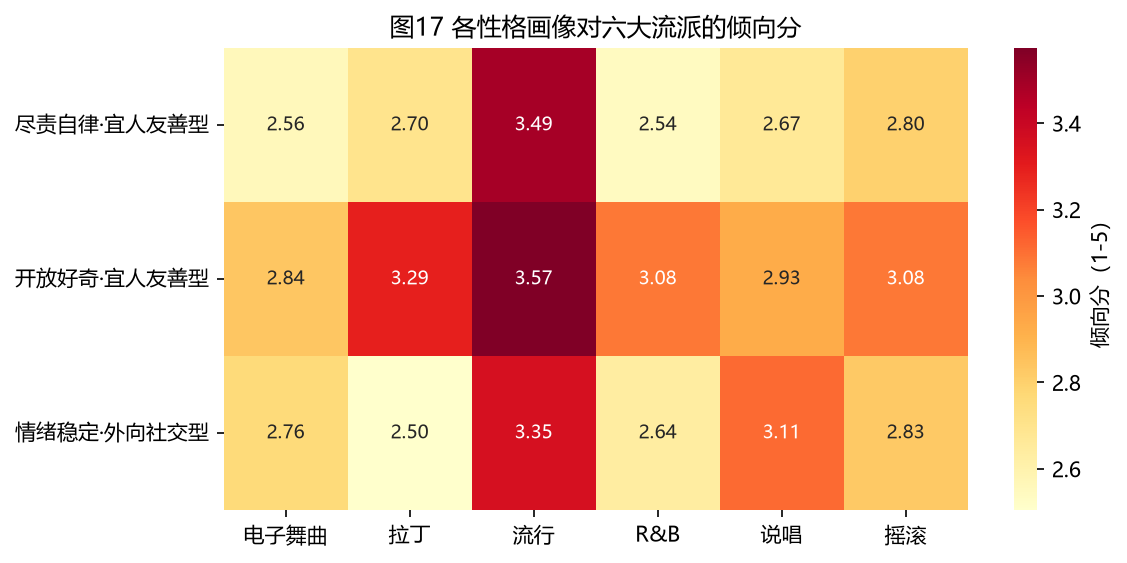

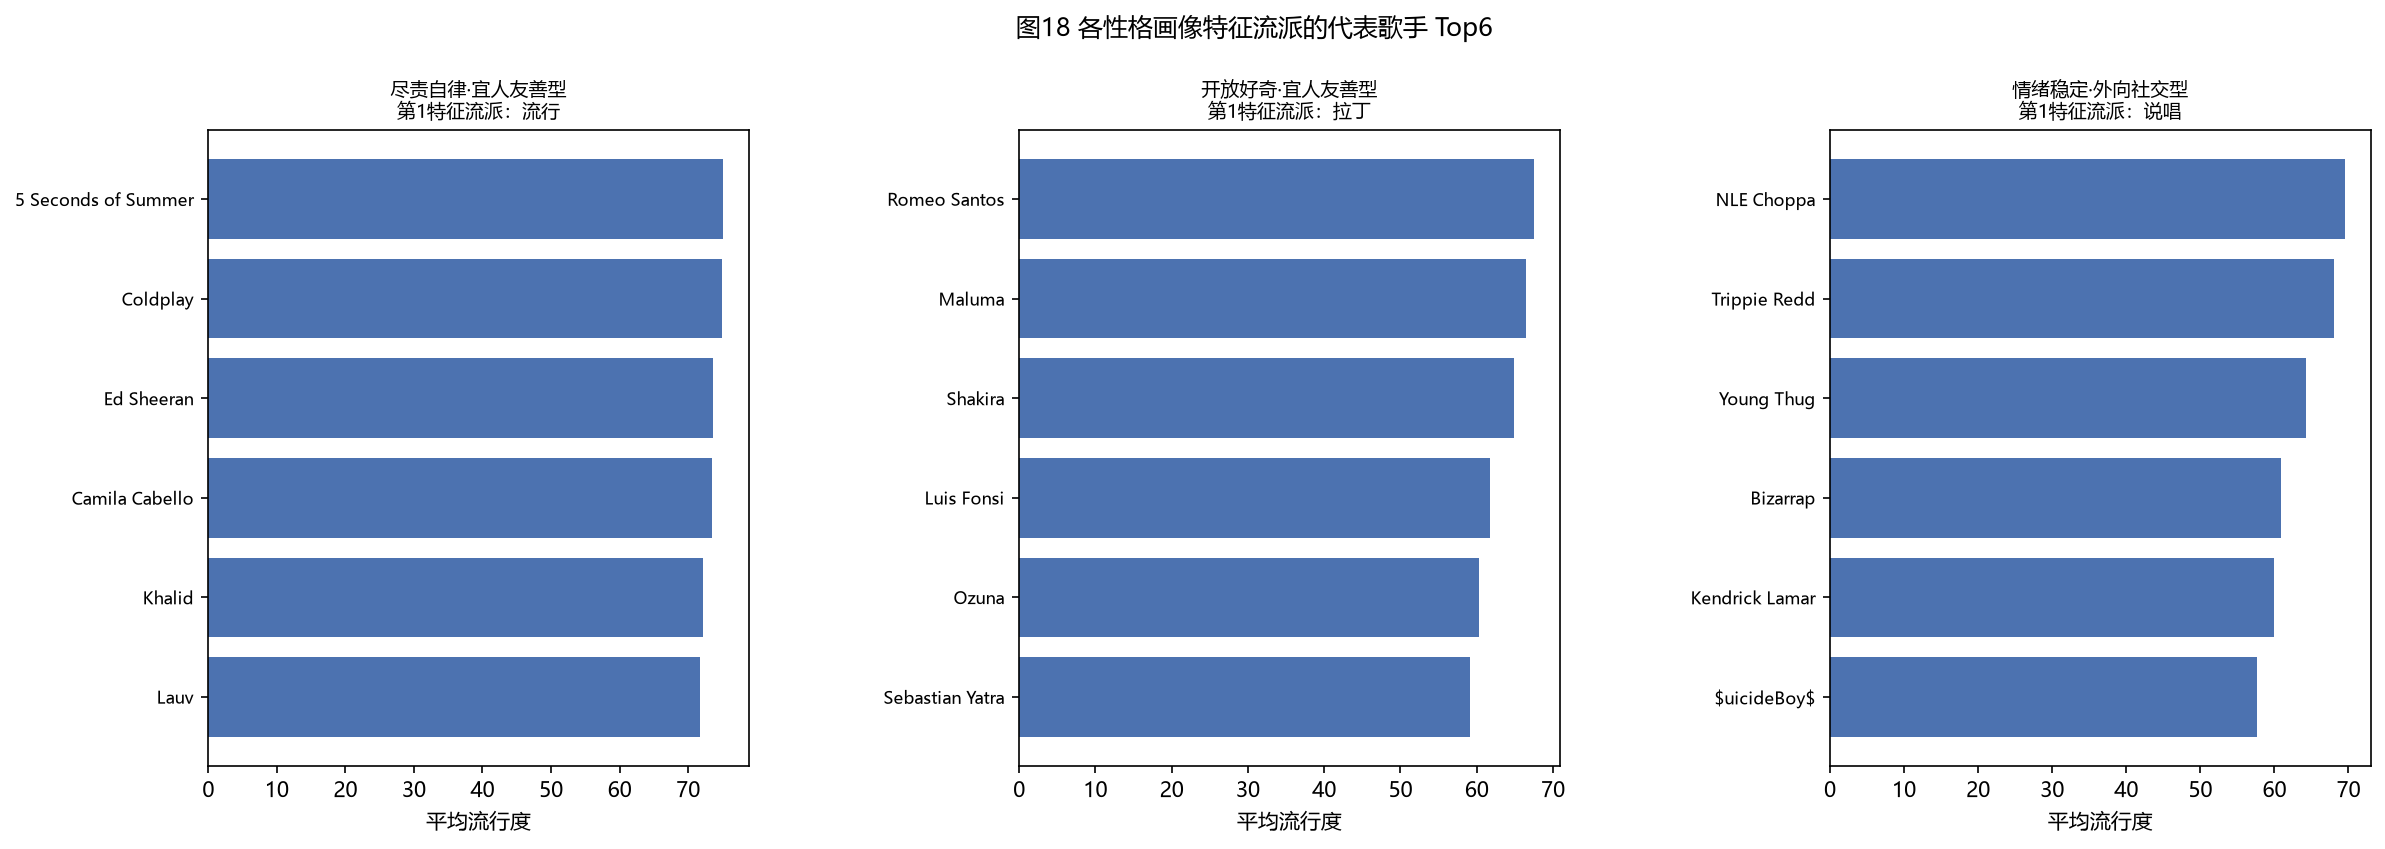

In [15]:
display(show_table("singer_survey_genre_detail.csv"))
show_fig("fig17_profile_spotify_genre.png", 720)
show_fig("fig18_profile_top_artists.png", 1100)

## 8. 结论与局限

### 主要结论

1. **年轻人可分为 3 个性格画像**：开放好奇·宜人友善型（35.5%）、情绪稳定·外向社交型（34.0%）、
   尽责自律·宜人友善型（30.5%）。其中「情绪稳定·外向社交型」女性仅占 36%，显著偏男性。
2. **性格画像与音乐口味显著相关**：17 个流派中 15 个在画像间差异达 p<0.05，
   差异最大的是音乐剧、歌剧、拉丁、爵士、古典。
3. **性格 → 歌手**：开放好奇型偏拉丁/R&B（Shakira、Billie Eilish、SZA）；
   外向社交型偏说唱/电音（Kendrick Lamar、Timmy Trumpet）；尽责自律型偏好均衡、最接近流行
   （Ed Sheeran、Coldplay）。
4. **画像可预测**：随机森林用易得信息预测画像准确率 **69.2%**，相对基线 35.5% 提升 33.7 个百分点。
5. **歌曲走红主要不由音频特征决定**：回归 R² 仅 0.173，音频特征相关系数全部弱于 |0.15|，
   发行年份反而是最强预测因子（新歌优势）。

### 局限（如实说明）

1. 问卷受访者为斯洛伐克 15~30 岁年轻人，偏好属欧美体系，结论适用于欧美流行音乐语境；
2. 两份数据不是同一批人，通过流派桥接，结论是群体倾向而非个体因果；
3. Spotify 数据仅 6 大流派，问卷中 5 个流派无对应歌手数据（而这恰是画像差异最大的部分）；
4. 性格维度为单题合成的代理指标，非标准化人格量表；
5. 轮廓系数均低于 0.2，画像之间存在重叠，不宜当作硬性分类边界使用。